
# 00 — Project overview and results walkthrough

This notebook is a **single entry point** for understanding the project without opening every script separately.

It is designed to answer four questions:

1. **What problem is being solved?**
2. **What data and simulation artifacts were generated?**
3. **What are the main results and exported figures?**
4. **How can someone reproduce the full pipeline locally?**

---

## What this project does

This repository studies **adaptive job-application interface selection** as a **contextual bandit** problem.

- Each round represents one simulated interaction between a user and the platform.
- The platform chooses one of several UI arms.
- Rewards depend on the simulated environment and the generated context.
- Multiple algorithms are compared on the same generated environment.

The repository contains both:
- the **code** used to generate and simulate the environment, and
- the **result artifacts** used for analysis and presentation.

---

## Notebook map

- `01_generator_diagnostics.ipynb` — generator checks and marginal summaries
- `02_reward_landscape.ipynb` — reward landscape by context / arm
- `03_bandit_results.ipynb` — main algorithm comparison plots
- `04_report_figures.ipynb` — export-ready report figures
- `05_final_additional_figures.ipynb` — optional appendix / extra assets
- `00_project_overview.ipynb` — this notebook, the single guided overview

This notebook intentionally does **not** regenerate the full million-scale run by default.
It is for **inspection, explanation, and presentation**.


In [1]:

from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == "notebooks" else cwd

data_dir = root / "data"
summ_dir = data_dir / "summaries"
raw_dir = data_dir / "raw"
logged_dir = data_dir / "logged"
processed_dir = data_dir / "processed"
out_dir = root / "outputs"
fig_dir = out_dir / "figures"
table_dir = out_dir / "tables"

print("Root:", root)
print("Figures dir exists:", fig_dir.exists())
print("Tables dir exists:", table_dir.exists())


Root: C:\Users\hovha\Downloads\gpt edit
Figures dir exists: True
Tables dir exists: True



## 1. High-level repository inventory

The next cell shows the lightweight summaries and the availability of the heavier generated artifacts.
This gives a fast sense of whether the repository is in a **code-only**, **lightweight**, or **full-results** state.


In [2]:

def size_mb(path):
    return round(path.stat().st_size / (1024 * 1024), 2)

rows = []

for folder in [raw_dir, summ_dir, logged_dir, processed_dir, fig_dir, table_dir]:
    if folder.exists():
        files = sorted([p for p in folder.iterdir() if p.is_file()])
        rows.append({
            "folder": str(folder.relative_to(root)),
            "file_count": len(files),
            "total_size_mb": round(sum(p.stat().st_size for p in files) / (1024 * 1024), 2),
            "example_files": ", ".join(p.name for p in files[:5])
        })

inv = pd.DataFrame(rows)
display(inv)


,folder,file_count,total_size_mb,example_files
0,data\raw,5,131.09,"applicants.parquet, arm_profiles.json, compani..."
1,data\summaries,9,89.06,"diagnostic_arm_by_context.csv, diagnostic_fit_..."
2,data\logged,16,908.91,".gitkeep, rounds_chunk_000.parquet, rounds_chu..."
3,data\processed,6,1522.74,".gitkeep, oracle_summary.parquet, rounds_all_m..."
4,outputs\figures,5,0.69,"arm_selection_frequency.png, cumulative_contex..."
5,outputs\tables,6,223.28,"algo_summary.csv, algo_summary.tex, arm_select..."



## 2. Main summary tables

These are the compact tables most useful for:
- the report,
- the slides,
- and a quick sanity check that results are present.

If a file is missing, the cell will skip it gracefully.


In [3]:

summary_files = [
    table_dir / "algo_summary.csv",
    table_dir / "arm_selection_frequency.csv",
    table_dir / "world_summary.csv",
]

for p in summary_files:
    if p.exists():
        display(Markdown(f"### `{p.name}`"))
        display(pd.read_csv(p))
    else:
        display(Markdown(f"### `{p.name}` — not found"))


### `algo_summary.csv`

,algo_name,mode,final_cumulative_reward,final_cumulative_expected_regret,mean_reward,interview_rate,ignore_rate
0,contextual_ts,online,151722.814605,10302.826091,0.144498,0.138494,0.591791
1,linucb,online,151293.077745,11028.819340,0.144089,0.138226,0.591774
2,gaussian_ts,online,143242.546418,18854.904983,0.136421,0.133746,0.603024
3,epsilon_greedy,online,144075.389520,19447.201136,0.137215,0.134265,0.604730
4,ucb1,online,140855.367225,22874.035496,0.134148,0.130350,0.613580


### `arm_selection_frequency.csv`

,algo_name,arm_selected_name,count,share
0,contextual_ts,card_grid,304352,0.289859
1,contextual_ts,guided_chat,51858,0.049389
2,contextual_ts,hybrid_ranked,317630,0.302505
3,contextual_ts,panel_split,325969,0.310447
4,contextual_ts,swipe_fast,50191,0.047801
5,epsilon_greedy,card_grid,41253,0.039289
6,epsilon_greedy,guided_chat,12271,0.011687
7,epsilon_greedy,hybrid_ranked,137407,0.130864
8,epsilon_greedy,panel_split,848505,0.808100
9,epsilon_greedy,swipe_fast,10564,0.010061


### `world_summary.csv`

,Unnamed: 0.1,Unnamed: 0,count,unique,top,freq,mean,std,min,25%,50%,75%,max
0,0,round_id,100000.0,NaN,NaN,NaN,49999.500000,28867.657797,0.000000,24999.750000,49999.500000,74999.250000,99999.000000
1,1,chunk_id,100000.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,session_id,100000.0,84971.0,session_0226996,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,applicant_id,100000.0,69199.0,person_0128595,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,job_id,100000.0,67401.0,job_00105722,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,113,exp_reward_panel_split,100000.0,NaN,NaN,NaN,0.157744,0.055504,0.019342,0.116725,0.152908,0.194393,0.405761
114,114,exp_reward_swipe_fast,100000.0,NaN,NaN,NaN,0.135430,0.050416,0.021457,0.097660,0.130488,0.168306,0.366441
115,115,exp_reward_card_grid,100000.0,NaN,NaN,NaN,0.148406,0.054081,0.018348,0.108004,0.143431,0.184046,0.385007
116,116,exp_reward_guided_chat,100000.0,NaN,NaN,NaN,0.152828,0.052688,0.017651,0.113918,0.148958,0.188279,0.387539



## 3. Main exported figures

These are the primary visual outputs currently used in the analysis:

- reward landscape
- cumulative contextual regret
- rolling realized reward
- arm selection frequency
- outcome mix by algorithm

The next cell renders them directly inside one notebook for presentation convenience.


## reward_landscape_heatmap.png

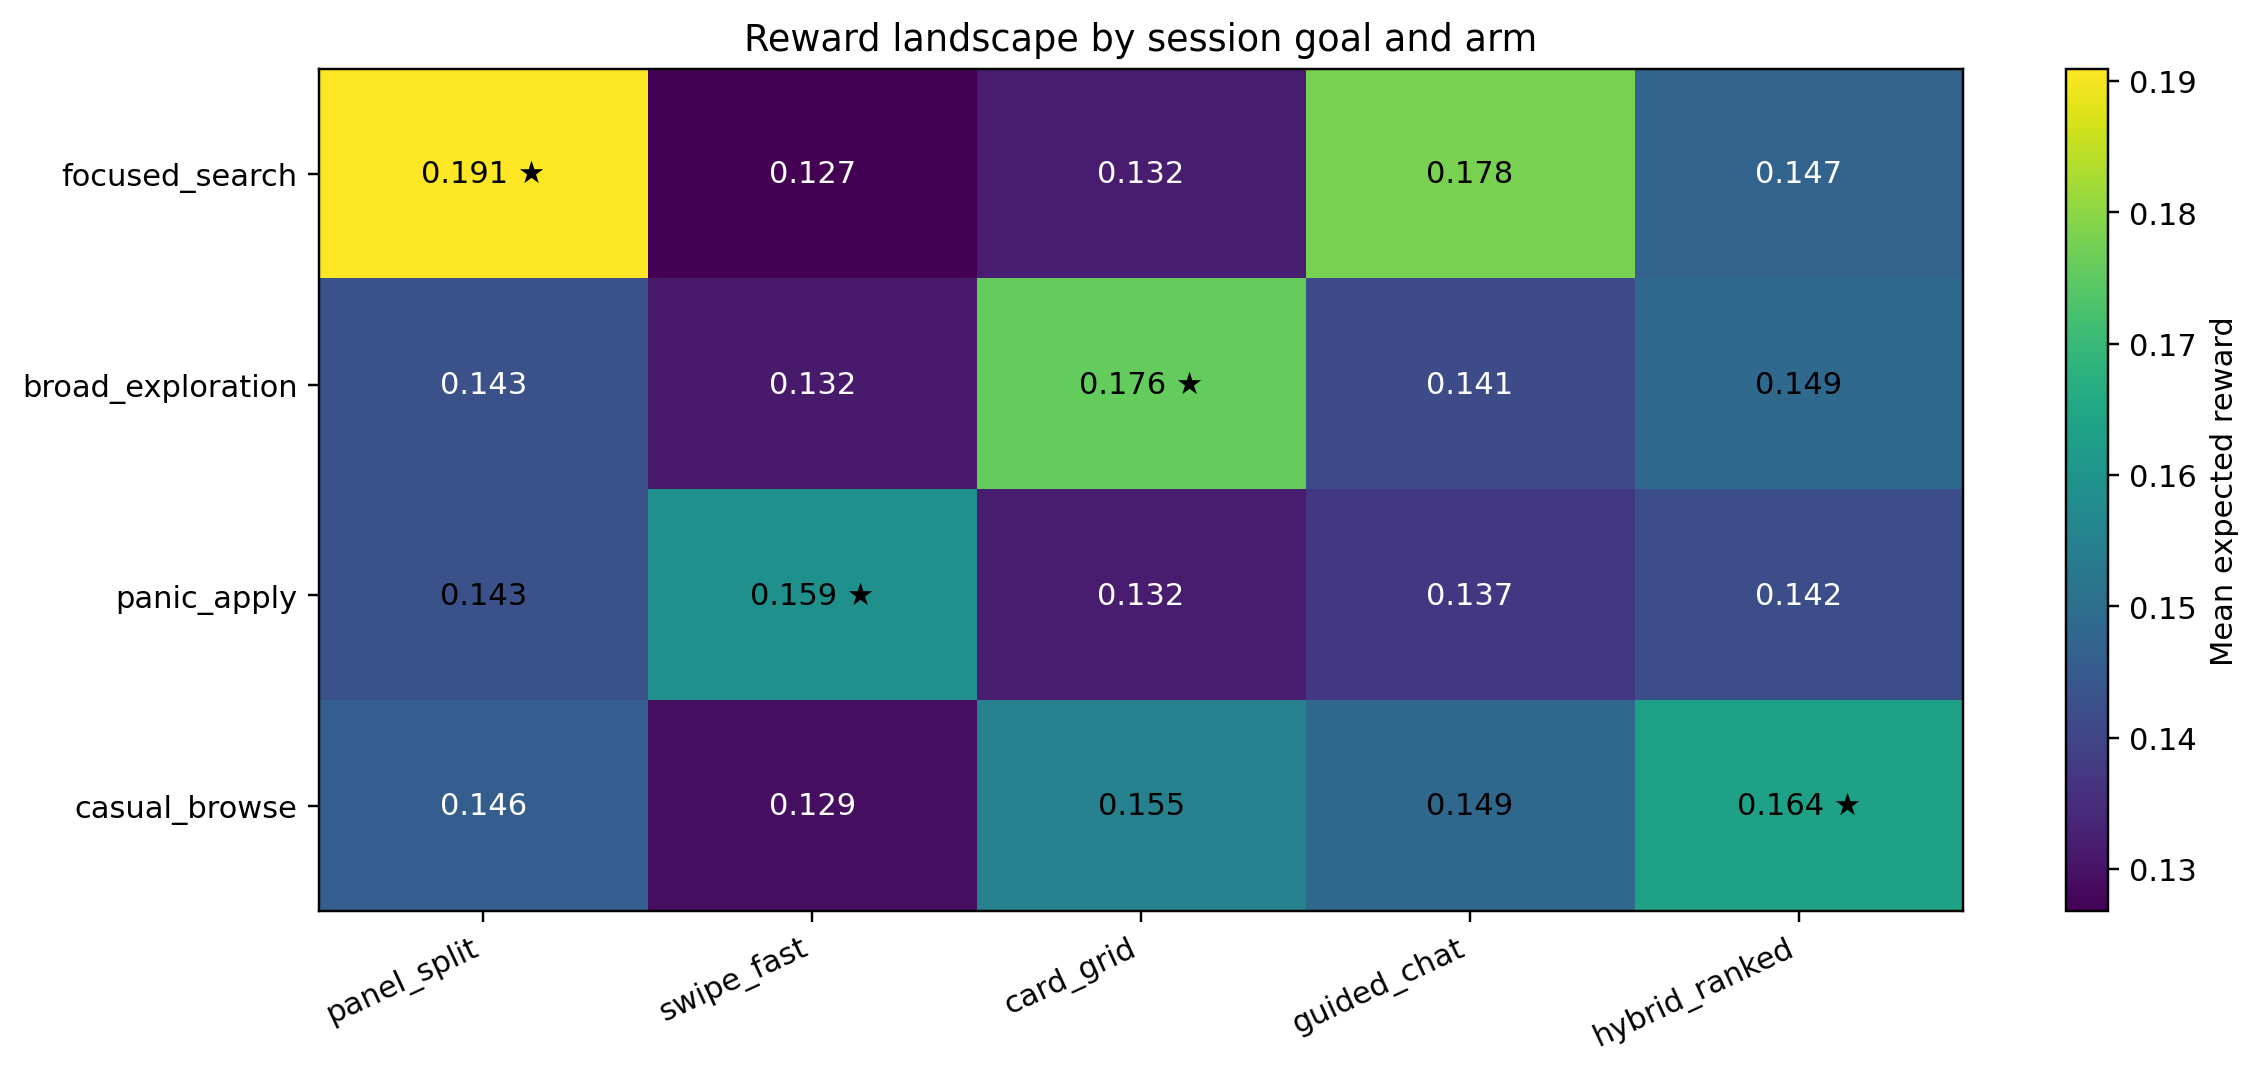

## cumulative_contextual_regret.png

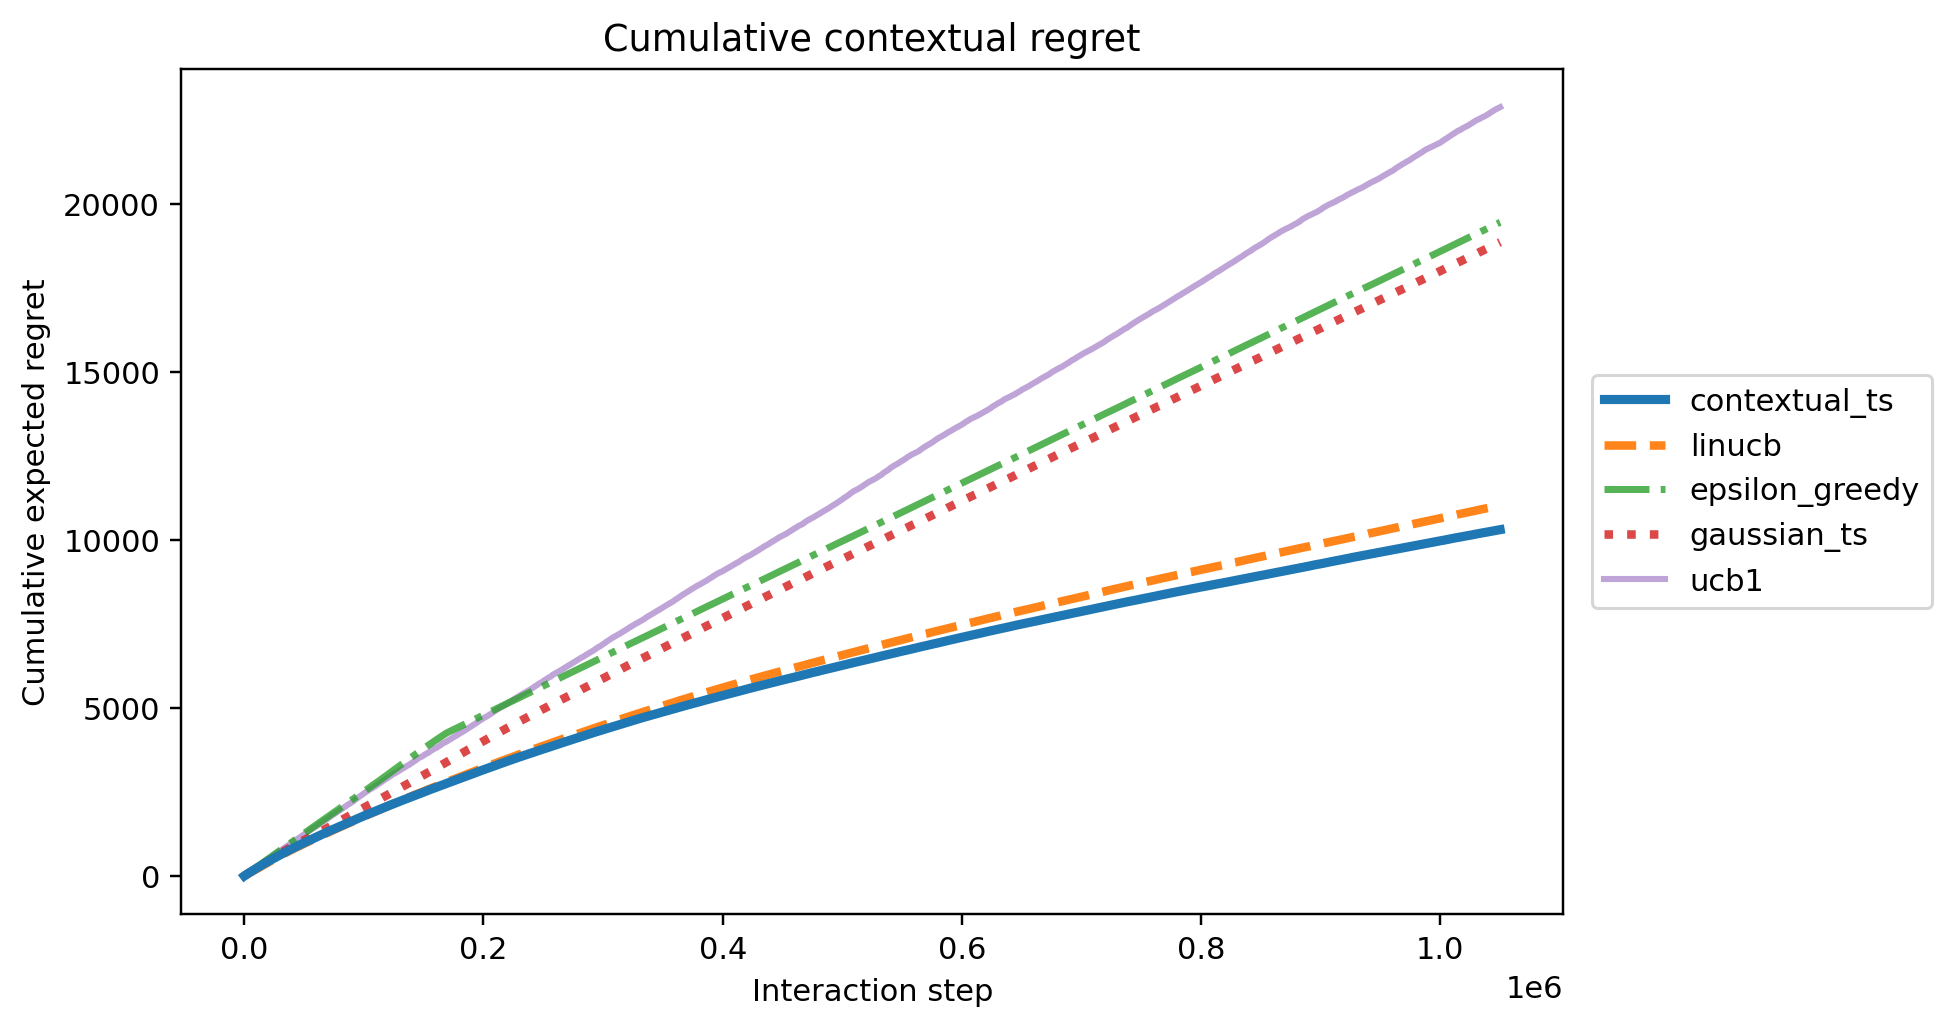

## rolling_avg_reward.png

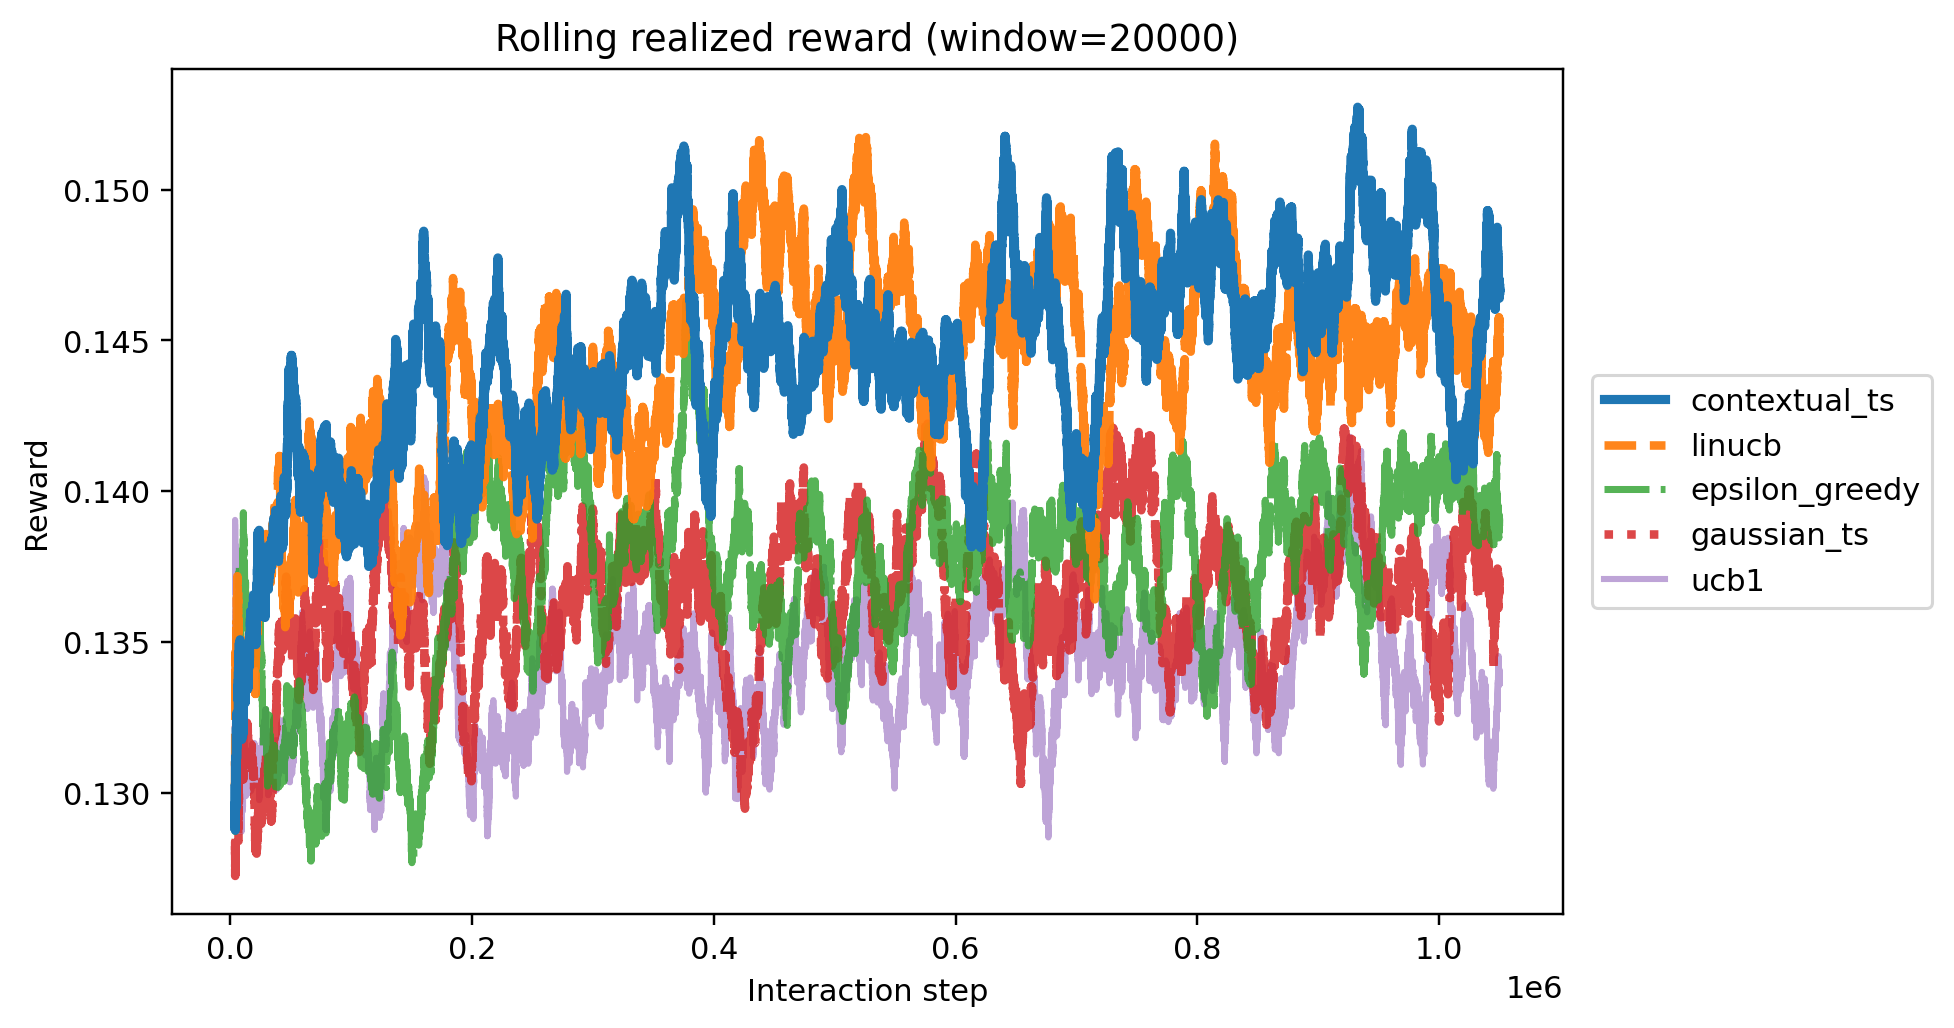

## arm_selection_frequency.png

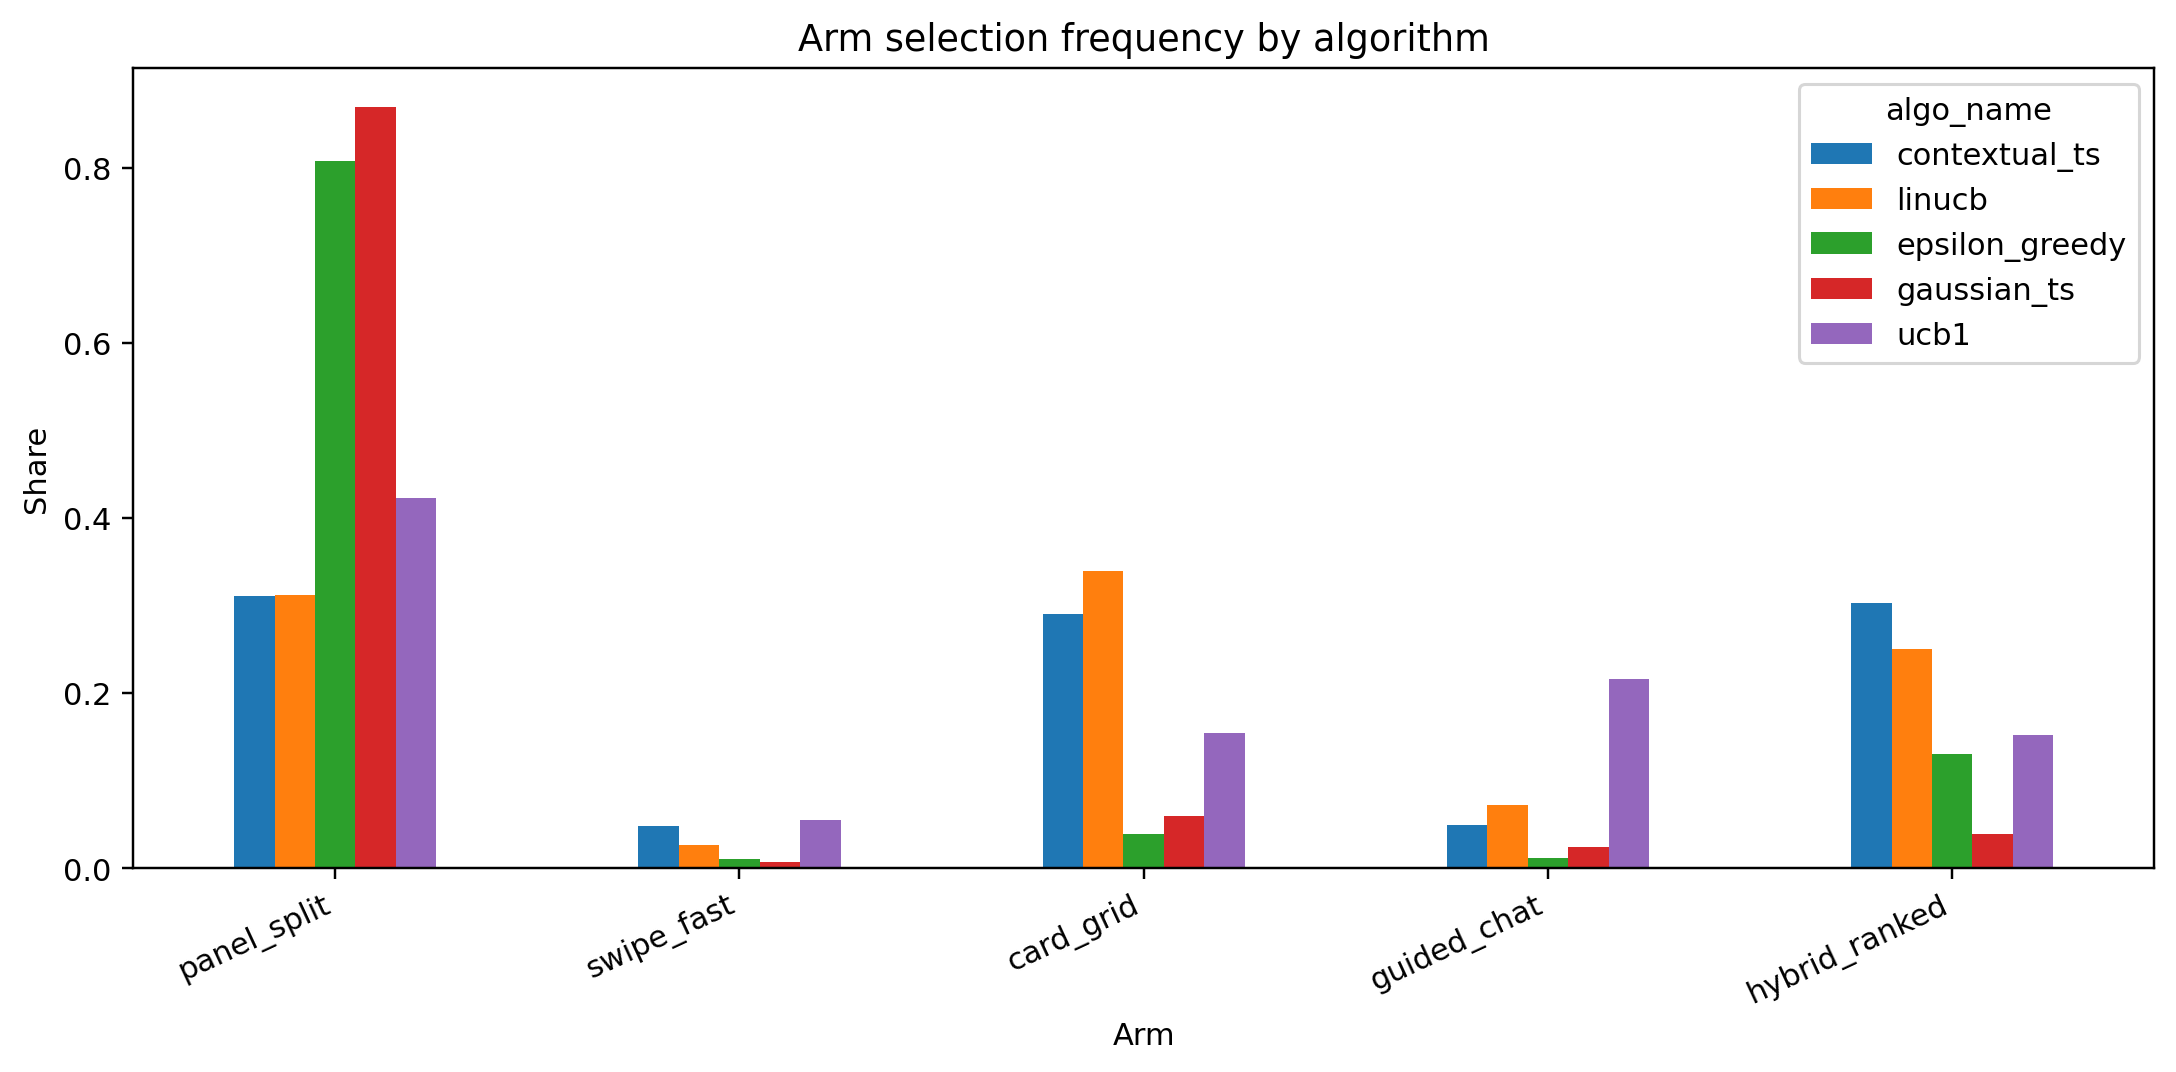

## outcome_mix_by_algorithm.png

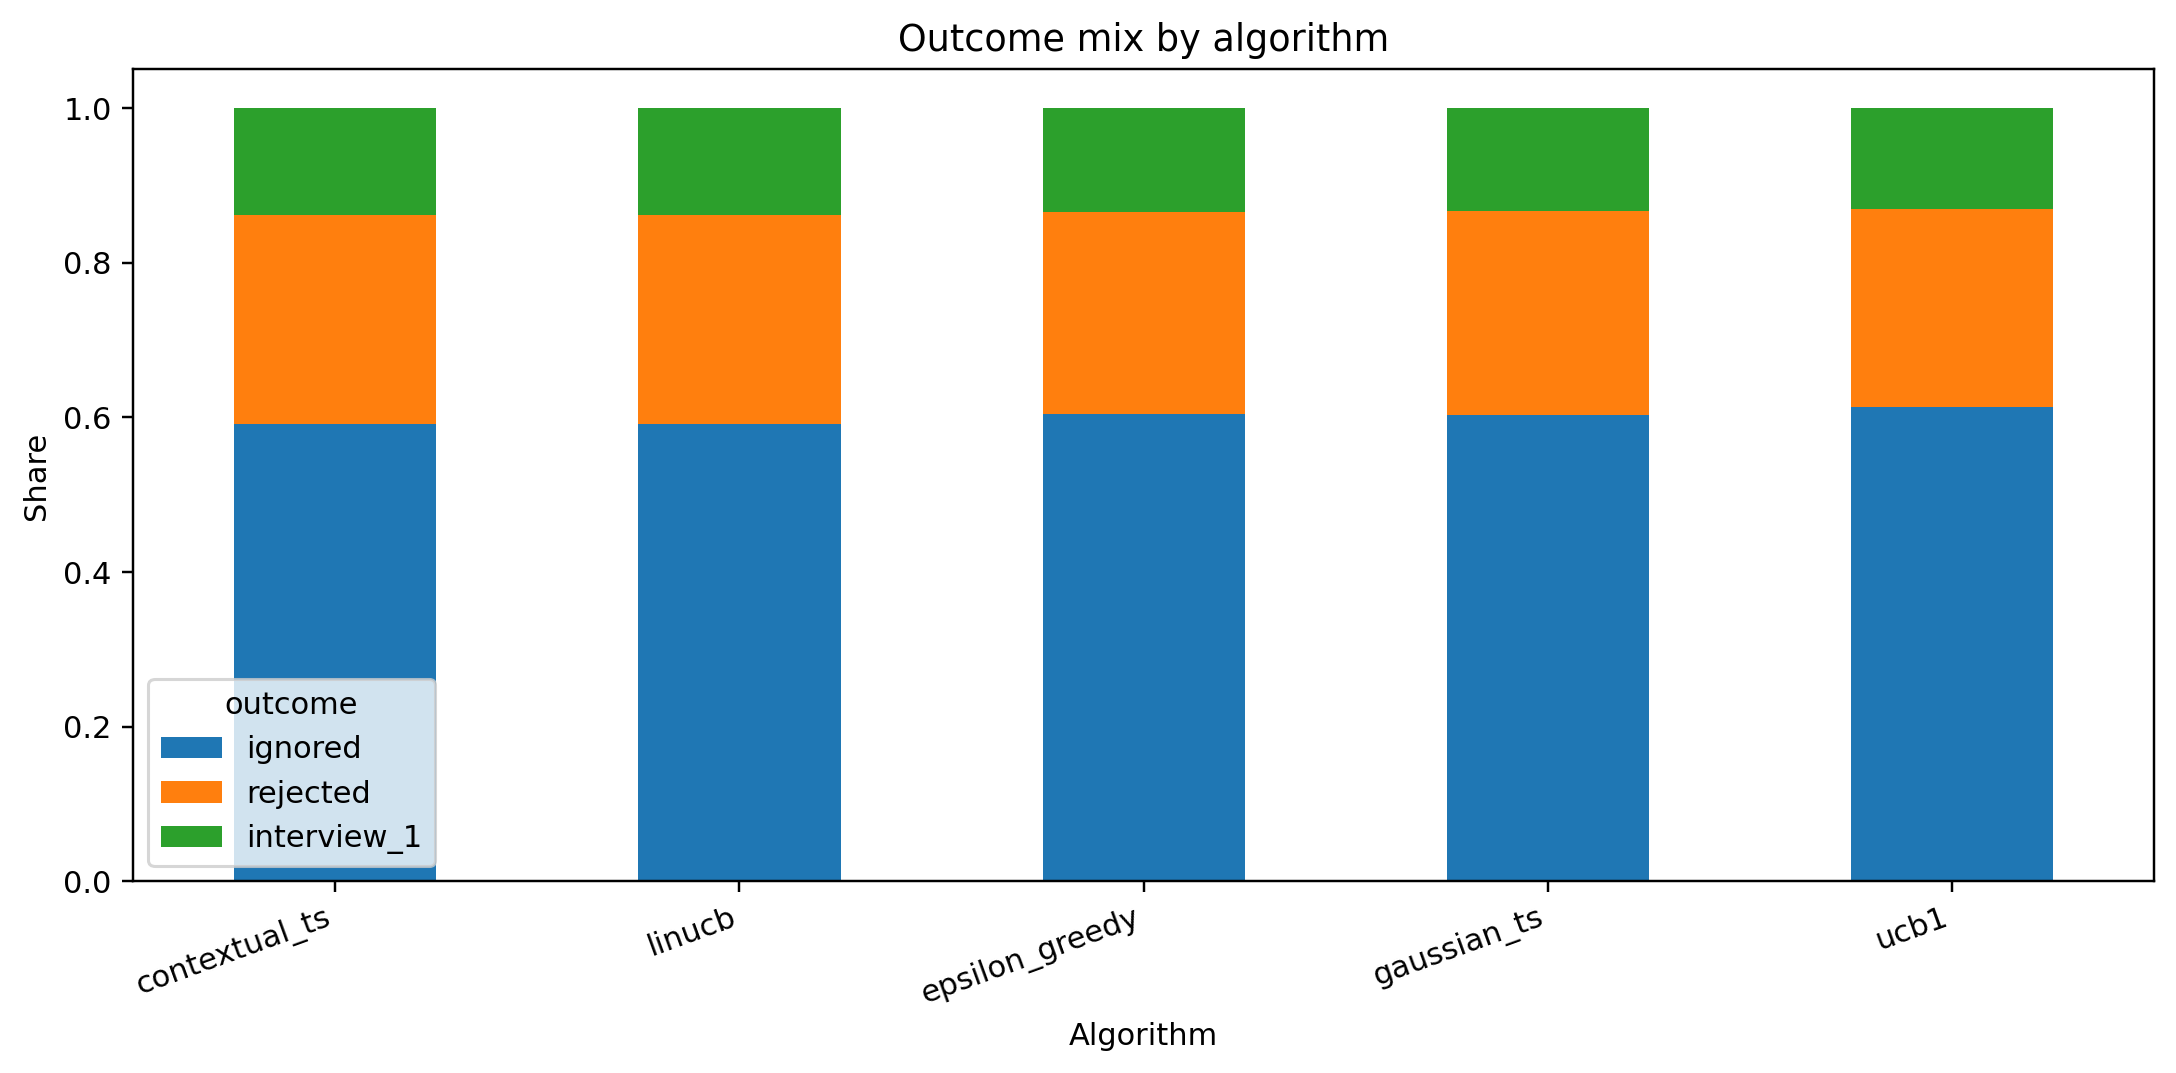

In [4]:

figure_order = [
    "reward_landscape_heatmap.png",
    "cumulative_contextual_regret.png",
    "rolling_avg_reward.png",
    "arm_selection_frequency.png",
    "outcome_mix_by_algorithm.png",
]

for name in figure_order:
    p = fig_dir / name
    display(Markdown(f"## {name}"))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown("_Not found_"))



## 4. Heavy artifacts and reproducibility notes

The repository may include large generated artifacts such as:

- raw parquet files,
- logged chunk parquet files,
- processed parquet files,
- and full experiment result parquets.

These are useful for **full reproducibility** and for showing the actual outputs produced after the long runs.

The next cell lists the large files currently present.


In [5]:

large_files = []

for folder in [raw_dir, logged_dir, processed_dir, table_dir]:
    if folder.exists():
        for p in folder.iterdir():
            if p.is_file() and p.stat().st_size > 10 * 1024 * 1024:
                large_files.append({
                    "path": str(p.relative_to(root)),
                    "size_mb": size_mb(p)
                })

large_df = pd.DataFrame(large_files).sort_values("size_mb", ascending=False) if large_files else pd.DataFrame(columns=["path", "size_mb"])
display(large_df)


,path,size_mb
17,data\processed\rounds_all_meta.parquet,750.94
19,data\processed\train_rounds.parquet,528.96
21,outputs\tables\experiment_results_full_online_...,223.25
20,data\processed\valid_rounds.parquet,121.44
18,data\processed\test_rounds.parquet,121.40
0,data\raw\applicants.parquet,63.60
10,data\logged\rounds_chunk_008.parquet,60.62
16,data\logged\rounds_chunk_014.parquet,60.61
15,data\logged\rounds_chunk_013.parquet,60.61
12,data\logged\rounds_chunk_010.parquet,60.61



## 5. How to regenerate the full pipeline locally

This project uses staged generation:

1. generate raw entities
2. simulate / merge processed rounds
3. run experiments
4. export report tables
5. export final figures

The commands below are shown as a **reference block only**.
They are not executed automatically from this notebook.


In [6]:

commands = r'''
# Windows CMD example
python -m src.export_report_tables --preset medium
python -m src.export_report_tables --preset full
python -m src.export_final_assets

# If you want to rerun the full end-to-end pipeline:
run_all.bat full

# Then regenerate notebook/export figures:
jupyter notebook
'''
print(commands)



# Windows CMD example
python -m src.export_report_tables --preset medium
python -m src.export_report_tables --preset full
python -m src.export_final_assets

# If you want to rerun the full end-to-end pipeline:
run_all.bat full

# Then regenerate notebook/export figures:
jupyter notebook




## 6. Interpretation guide

A short reading guide for the main results:

- **Reward landscape heatmap**  
  Shows which arm is best for each context row.

- **Cumulative contextual regret**  
  Lower is better. This is the clearest algorithm-comparison plot.

- **Rolling realized reward**  
  Smoothed reward trajectory over time.

- **Arm selection frequency**  
  Shows how often each algorithm chooses each arm.

- **Outcome mix**  
  Useful as a backup / appendix figure rather than the main headline figure.

---

## Suggested use in grading / demo

If the instructor or grader wants a single notebook:
- open this notebook first,
- then jump into the more specialized notebooks only if needed.

That gives a much cleaner walkthrough than starting from raw scripts.
